<a href="https://colab.research.google.com/github/mavzunaa/FillArray-Task1/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install sklearn-som

In [6]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn_som.som import SOM
from scipy.cluster.hierarchy import dendrogram, linkage
import pandas as pd

In [8]:
data = pd.read_csv('data4.csv', sep=',')
data.head()

,R0,R1,R2,R3,R4,D1,D2,D3,D4
0,0.86,0.86,0.89,0.83,0.79,0.00,0.00,0.01,0.00
1,0.82,0.80,0.87,0.87,0.84,0.02,0.01,0.01,0.01
2,0.87,0.87,0.86,0.84,0.74,0.01,0.01,0.00,0.00
3,0.73,0.82,0.83,0.83,0.83,0.01,0.01,0.01,0.01
4,0.85,0.86,0.86,0.86,0.85,0.00,0.00,0.00,0.01


In [9]:
k = 4

In [12]:
clustering_kmeans = KMeans(n_clusters=k).fit(data)
print(clustering_kmeans.labels_)

[2 2 0 2 2 2 2 3 2 0 0 2 2 2 2 0 0 2 2 1 0 2 1 1 2 0 0 3 1 0 0 0 0 2 2 2 2
 1 0 2 2 1 2 1 2 0 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 1 2 1
 0 2 2]


In [13]:
clustering_aggle = AgglomerativeClustering(n_clusters=k).fit(data)
print(clustering_aggle.labels_)

[2 2 1 2 2 2 2 0 2 1 1 2 2 2 2 1 2 2 2 1 1 2 3 3 2 1 1 0 0 0 1 1 2 2 2 2 2
 1 3 2 2 1 2 3 2 1 2 2 2 2 0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 3 2 1
 2 2 2]


In [14]:
clustering_dbscan = DBSCAN(eps=0.1, min_samples=2).fit(data)
print(clustering_dbscan.labels_)

[ 0  0  0  1  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0 -1  0  0 -1 -1
  0 -1  0 -1 -1 -1  0 -1  0  0  0  0  0 -1 -1  0  0 -1  0 -1  0  0  0  0
  0  0 -1  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0 -1
  0 -1  0  0  0]


In [15]:
print(clustering_kmeans.cluster_centers_)

[[0.851      0.849      0.8275     0.775      0.741      0.0335
  0.0245     0.0225     0.024     ]
 [0.81888889 0.75222222 0.69222222 0.66333333 0.59333333 0.07777778
  0.05555556 0.05222222 0.04777778]
 [0.85608696 0.86152174 0.85391304 0.8476087  0.83847826 0.00869565
  0.00869565 0.01021739 0.01108696]
 [0.335      0.835      0.605      0.775      0.555      0.01
  0.015      0.005      0.045     ]]


In [21]:
som = SOM(m=k//2, n=k//2, dim=data.shape[1])
som.fit(data.to_numpy())
clusters_som = som.predict(data.to_numpy())
print(clusters_som)

[2 2 0 2 2 2 2 1 2 0 1 2 2 2 2 0 3 2 2 1 1 0 1 1 0 1 1 1 1 1 0 1 0 3 3 2 2
 1 1 2 2 1 2 1 0 1 2 2 2 2 2 1 2 3 3 2 2 2 2 2 0 2 3 2 2 2 2 3 1 1 0 1 2 1
 0 2 3]


In [28]:
data['kmeans'] = clustering_kmeans.labels_
data['aggle'] = clustering_aggle.labels_
data['dbscan'] = clustering_dbscan.labels_
data['som'] = clusters_som
pd.set_option('display.max_rows', None)
print(data)

      R0    R1    R2    R3    R4    D1    D2    D3    D4  kmeans  aggle  \
0   0.86  0.86  0.89  0.83  0.79  0.00  0.00  0.01  0.00       2      2   
1   0.82  0.80  0.87  0.87  0.84  0.02  0.01  0.01  0.01       2      2   
2   0.87  0.87  0.86  0.84  0.74  0.01  0.01  0.00  0.00       0      1   
3   0.73  0.82  0.83  0.83  0.83  0.01  0.01  0.01  0.01       2      2   
4   0.85  0.86  0.86  0.86  0.85  0.00  0.00  0.00  0.01       2      2   
5   0.89  0.89  0.89  0.86  0.87  0.00  0.01  0.00  0.00       2      2   
6   0.86  0.86  0.86  0.87  0.88  0.01  0.01  0.01  0.01       2      2   
7   0.19  0.86  0.61  0.85  0.61  0.00  0.00  0.01  0.00       3      0   
8   0.85  0.86  0.88  0.83  0.82  0.03  0.02  0.01  0.02       2      2   
9   0.90  0.89  0.89  0.82  0.75  0.00  0.01  0.01  0.00       0      1   
10  0.85  0.86  0.83  0.73  0.77  0.01  0.01  0.01  0.01       0      1   
11  0.87  0.86  0.84  0.86  0.81  0.00  0.01  0.01  0.01       2      2   
12  0.88  0.88  0.88  0.8

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [35.0, 35.0, 45.0, 45.0],
  [20.0, 20.0, 40.0, 40.0],
  [5.0, 5.0, 30.0, 30.0],
  [95.0, 95.0, 105.0, 105.0],
  [85.0, 85.0, 100.0, 100.0],
  [75.0, 75.0, 92.5, 92.5],
  [115.0, 115.0, 125.0, 125.0],
  [135.0, 135.0, 145.0, 145.0],
  [165.0, 165.0, 175.0, 175.0],
  [205.0, 205.0, 215.0, 215.0],
  [195.0, 195.0, 210.0, 210.0],
  [185.0, 185.0, 202.5, 202.5],
  [170.0, 170.0, 193.75, 193.75],
  [155.0, 155.0, 181.875, 181.875],
  [235.0, 235.0, 245.0, 245.0],
  [255.0, 255.0, 265.0, 265.0],
  [240.0, 240.0, 260.0, 260.0],
  [225.0, 225.0, 250.0, 250.0],
  [168.4375, 168.4375, 237.5, 237.5],
  [140.0, 140.0, 202.96875, 202.96875],
  [120.0, 120.0, 171.484375, 171.484375],
  [83.75, 83.75, 145.7421875, 145.7421875],
  [65.0, 65.0, 114.74609375, 114.74609375],
  [55.0, 55.0, 89.873046875, 89.873046875],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [72.4365234375, 72.4365234375, 282.5, 282.5],
  [17.5, 17.5, 177.46826171875, 177.46

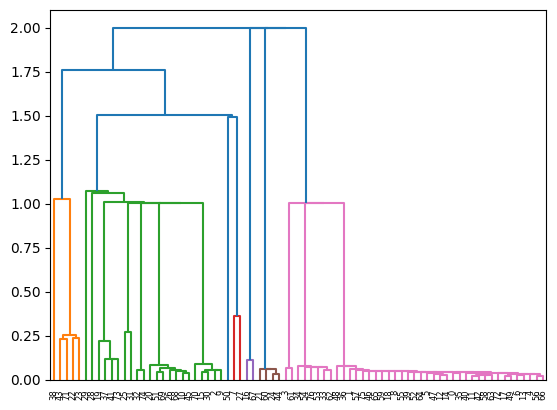

In [38]:
from scipy.cluster.hierarchy import linkage # Re-import to ensure 'linkage' refers to the function
links = linkage(data)
dendrogram(links)